In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

### import cats

In [2]:
cats="C:/Users/anand/OneDrive/PGA-54 TOOLS/DEEP LEARNING/Datasets/Cats and dogs data/cats/"
cats

'C:/Users/anand/OneDrive/PGA-54 TOOLS/DEEP LEARNING/Datasets/Cats and dogs data/cats/'

In [3]:
cats_names=os.listdir(cats)

In [4]:
len(cats_names)

1000

### Import Dogs

In [5]:
dogs="C:/Users/anand/OneDrive/PGA-54 TOOLS/DEEP LEARNING/Datasets/Cats and dogs data/dogs/"
dogs

'C:/Users/anand/OneDrive/PGA-54 TOOLS/DEEP LEARNING/Datasets/Cats and dogs data/dogs/'

In [6]:
dogs

'C:/Users/anand/OneDrive/PGA-54 TOOLS/DEEP LEARNING/Datasets/Cats and dogs data/dogs/'

In [7]:
dogs_names=os.listdir("C:/Users/anand/OneDrive/PGA-54 TOOLS/DEEP LEARNING/Datasets/Cats and dogs data/dogs/")

In [8]:
len(dogs_names)

1000

In [9]:
c1=cv2.imread(cats+cats_names[0])

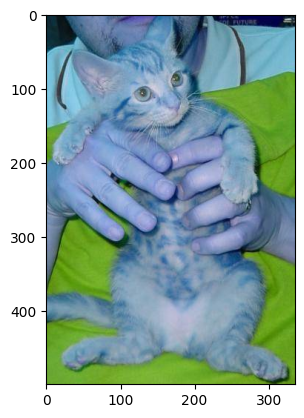

In [10]:
plt.imshow(c1)

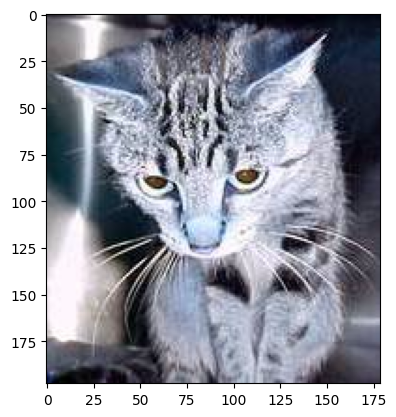

In [11]:
c2=cv2.imread(cats+cats_names[1])
plt.imshow(c2)

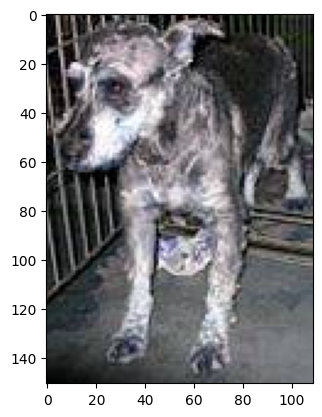

In [12]:
d1=cv2.imread(dogs+dogs_names[0])
plt.imshow(d1)

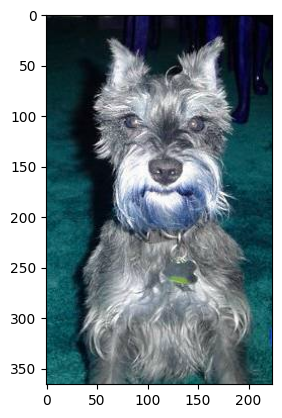

In [13]:
d2=cv2.imread(dogs+dogs_names[1])
plt.imshow(d2)

### Shape of images

In [14]:
c1.shape

(499, 336, 3)

In [15]:
c2.shape

(198, 179, 3)

In [16]:
d1.shape

(151, 109, 3)

In [17]:
d2.shape

(366, 224, 3)

#### Now i am reshaping all images into 300,300

In [18]:
import time

In [19]:
for names in cats_names:
    c_img=cv2.imread(cats+names)
    c_img=cv2.resize(c_img,(300,300))
    c_img=np.array(c_img)
    dataset.append(c_img)
    labels.append(c_img)
    print(c_img.shape)
    time.sleep(0.5)

NameError: name 'dataset' is not defined

In [20]:
dataset=[]

In [21]:
labels=[]

In [22]:
for names in cats_names:
    c_img=cv2.imread(cats+names)
    c_img=cv2.resize(c_img,(300,300))
    c_img=np.array(c_img)
    dataset.append(c_img)
    labels.append(0)

In [23]:
len(dataset)

1000

In [24]:
len(labels)

1000

#### Dogs resize

###

In [25]:
for names in dogs_names:
    d_img=cv2.imread(dogs+names)
    d_img=cv2.resize(d_img,(300,300))
    d_img=np.array(d_img)
    dataset.append(d_img)
    labels.append(1)

In [26]:
len(dataset)

2000

In [27]:
len(labels)

2000

In [28]:
type(dataset)

list

In [29]:
type(labels)

list

#### Now converting list datatype to array

In [30]:
ary_dataset=np.array(dataset)

In [31]:
ary_labels=np.array(labels)

In [32]:
pd.DataFrame(labels).value_counts()

0
0    1000
1    1000
Name: count, dtype: int64

In [33]:
x=ary_dataset.copy()
y=ary_labels.copy()

In [34]:
x.shape

(2000, 300, 300, 3)

In [35]:
y.shape

(2000,)

### Split

In [36]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=2)

In [37]:
x_train.shape

(1600, 300, 300, 3)

In [38]:
x_test.shape

(400, 300, 300, 3)

### scaling

In [39]:
x_train.max()

np.uint8(255)

In [40]:
x_test.max()

np.uint8(255)

In [41]:
x_train_scale=x_train/255

In [42]:
x_test_scale=x_test/255

In [43]:
x_train.shape

(1600, 300, 300, 3)

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D,Flatten,Dense

In [45]:
cnn=Sequential()

In [46]:
cnn.add(Input(shape=(300,300,3)))

### 1st Convulational layer

In [47]:
cnn.add(Conv2D(filters=32,kernel_size=(3,3),strides=(1,1),padding="valid",activation="relu"))

In [48]:
cnn.add(MaxPooling2D(pool_size=(2,2),padding="valid"))

### 2nd Convulational layer

In [49]:
cnn.add(Conv2D(filters=40,kernel_size=(3,3),strides=(1,1),padding="valid",activation="relu"))

In [50]:
cnn.add(MaxPooling2D(pool_size=(2,2),padding="valid"))

### Fully connected layers


In [51]:
cnn.add(Flatten())
cnn.add(Dense(64,activation="relu"))
cnn.add(Dense(128,activation="relu"))
cnn.add(Dense(256,activation="relu"))
cnn.add(Dense(2,activation="softmax"))

In [52]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 298, 298, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 147, 147, 40)   │        11,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 213160)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    13,642,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,696,618 (52.25 MB)

 Trainable params: 13,696,618 (52.25 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
cnn.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])

In [55]:
cnn.fit(x_train_scale,y_train,epochs=5)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.9775 - loss: 0.1114
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 991ms/step - accuracy: 0.9925 - loss: 0.0330
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.9887 - loss: 0.0372
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9906 - loss: 0.0290
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9944 - loss: 0.0130


In [56]:
cnn.evaluate(x_train_scale,y_train)

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 234ms/step - accuracy: 0.9962 - loss: 0.0151


[0.015095586888492107, 0.9962499737739563]

In [57]:
x_train_scale.shape

(1600, 300, 300, 3)

### p1

In [58]:
p1=x_train_scale[200].reshape((1,)+x_train_scale[200].shape)

In [59]:
cnn.predict(p1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step


array([[9.9996936e-01, 3.0654188e-05]], dtype=float32)

In [60]:
np.argmax(cnn.predict(p1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


np.int64(0)

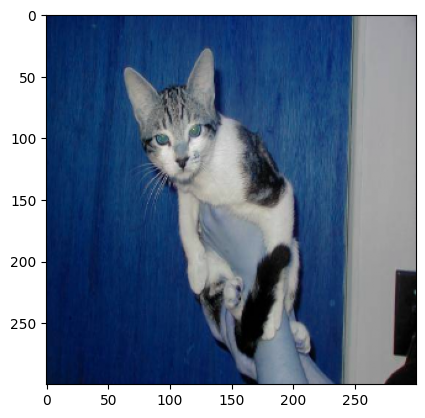

In [61]:
plt.imshow(x_train_scale[200])

In [70]:
y_train[200]

np.int64(0)

### p2

In [62]:
p2=x_test_scale[200].reshape((1,)+x_test_scale[200].shape)

In [63]:
cnn.predict(p2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


array([[2.6917792e-04, 9.9973077e-01]], dtype=float32)

In [64]:
np.argmax(cnn.predict(p2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


np.int64(1)

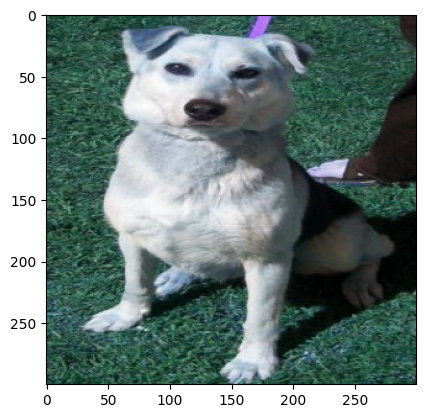

In [68]:
plt.imshow(x_test_scale[200])